# Moto Sense

## Library

In [1]:
import os, glob, shutil, random, warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import librosa
import soundfile as sf

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import Sequential, layers, regularizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

from audiomentations import (
    Compose, AddGaussianNoise, PitchShift,
    TimeStretch, Shift, PolarityInversion
)

import matplotlib.pyplot as plt
import seaborn as sns


## Konfigurasi 

In [2]:

# ── Konfigurasi ──────────────────────────────────────────────
CLASSES = ["Clutch-Shoe", "Conecting-Rod", "Drive-Belt", "Piston", "Tensioner", "Slider", "Roller", "Face-Drive"]
BASE_DIR      = "Dataset"
TARGET_SR     = 16000
DURATION      = 3
TARGET_SAMPLES = TARGET_SR * DURATION  # 48.000
STRIDE_SAMPLES = int(TARGET_SR * 1.5)

# Mel-Spectrogram — shape output: (128, 128)
N_MELS       = 128
N_FFT        = 1024
HOP_LENGTH   = 375  # 48000 / 375 = 128 frame tepat

# Augmentasi
AUG_TARGET   = 100  # minimal per kelas di training

# Training
BATCH_SIZE   = 8
EPOCHS       = 100
SEED         = 42

# ── Folder paths ─────────────────────────────────────────────
PATHS = {
    "raw"         : os.path.join(BASE_DIR, "part-rusak"),
    "rename"      : os.path.join(BASE_DIR, "rename"),
    "split_orig"  : os.path.join(BASE_DIR, "split_original"),
    "prep_train"  : os.path.join(BASE_DIR, "preprocesed", "train"),
    "prep_val"    : os.path.join(BASE_DIR, "preprocesed", "val"),
    "prep_test"   : os.path.join(BASE_DIR, "preprocesed", "test"),
    "aug_train"   : os.path.join(BASE_DIR, "augmented", "train"),
    "features"    : os.path.join(BASE_DIR, "features"),
    "models"      : "models",
}
for p in PATHS.values():
    os.makedirs(p, exist_ok=True)



## Load Data

In [3]:
# BASE_DIR = "dataset"
# IN_DIR = os.path.join(BASE_DIR, "part-rusak")
# CLASSES = ["Clutch-Shoe", "Conecting-Rod", "Drive-Belt", "Piston", "Tensioner", "Slider", "Roller", "Face-Drive"]

for cls in CLASSES:
    path = os.path.join(PATHS['raw'], cls)
    
    if os.path.exists(path):
        jml_file = len(os.listdir(path))
        print(f"{cls}: {jml_file}")
    else:
        print(f"{cls}: Folder tidak ditemukan")

Clutch-Shoe: 15
Conecting-Rod: 10
Drive-Belt: 20
Piston: 6
Tensioner: 8
Slider: 13
Roller: 19
Face-Drive: 9


## EDA

In [4]:
durasi_dict = {}

print(f"{'KELAS':<15} | {'FILE':<5} | {'SAMPLE RATE':<12} | {'RATA-RATA':<10} | {'MIN':<6} | {'MAX':<6}")
print("-" * 75)

for cls in CLASSES:
    path = os.path.join(PATHS['raw'], cls)

    if not os.path.exists(path):
        continue

    files = [f for f in os.listdir(path) if f.endswith(('.wav', '.mp3'))]

    if not files:
        continue

    durasi_list = [
        librosa.get_duration(path=os.path.join(path, f))
        for f in files
    ]

    # Ambil sample rate dari file pertama
    _, sr = librosa.load(
        os.path.join(path, files[0]),
        sr=None
    )

    durasi_dict[cls] = durasi_list

    print(
        f"{cls:<15} | "
        f"{len(files):<5} | "
        f"{sr:<12} | "
        f"{np.mean(durasi_list):<8.2f}s | "
        f"{np.min(durasi_list):<4.2f}s | "
        f"{np.max(durasi_list):<4.2f}s"
    )

KELAS           | FILE  | SAMPLE RATE  | RATA-RATA  | MIN    | MAX   
---------------------------------------------------------------------------
Clutch-Shoe     | 15    | 44100        | 2.51    s | 1.07s | 4.08s
Conecting-Rod   | 10    | 44100        | 2.37    s | 1.62s | 4.21s
Drive-Belt      | 20    | 44100        | 3.55    s | 1.60s | 6.75s
Piston          | 6     | 44100        | 1.74    s | 1.00s | 3.17s
Tensioner       | 8     | 44100        | 2.97    s | 1.59s | 7.41s
Slider          | 13    | 44100        | 3.91    s | 0.84s | 6.51s
Roller          | 19    | 44100        | 3.78    s | 1.53s | 9.15s
Face-Drive      | 9     | 44100        | 3.14    s | 1.20s | 4.82s


In [5]:
for cls in CLASSES:
    path = os.path.join(PATHS['raw'], cls)

    if not os.path.exists(path):
        continue

    print(f"\n--- Kelas: {cls} ---")

    files = sorted([
        f for f in os.listdir(path)
        if f.endswith(('.wav', '.mp3', '.m4a'))
    ])

    for f in files:
        file_path = os.path.join(path, f)

        # Durasi
        durasi = librosa.get_duration(path=file_path)

        # Sample Rate
        _, sr = librosa.load(file_path, sr=None)

        nama_file = os.path.splitext(f)[0]

        if durasi >= 60:
            menit = int(durasi // 60)
            detik = int(durasi % 60)

            print(
                f"{nama_file:<30} | "
                f"{menit} menit {detik} detik | "
                f"SR: {sr} Hz"
            )
        else:
            print(
                f"{nama_file:<30} | "
                f"{durasi:.2f} detik | "
                f"SR: {sr} Hz"
            )


--- Kelas: Clutch-Shoe ---
Clutch-Shoe-1                  | 2.51 detik | SR: 44100 Hz
Clutch-Shoe-13                 | 3.61 detik | SR: 44100 Hz
Clutch-Shoe-14                 | 1.93 detik | SR: 44100 Hz
Clutch-Shoe-16                 | 2.33 detik | SR: 44100 Hz
Clutch-Shoe-17                 | 2.92 detik | SR: 44100 Hz
Clutch-Shoe-2                  | 1.48 detik | SR: 44100 Hz
Clutch-Shoe-20                 | 2.67 detik | SR: 44100 Hz
Clutch-Shoe-23                 | 2.17 detik | SR: 44100 Hz
Clutch-Shoe-25                 | 3.12 detik | SR: 44100 Hz
Clutch-Shoe-27                 | 4.05 detik | SR: 44100 Hz
Clutch-Shoe-28                 | 1.40 detik | SR: 44100 Hz
Clutch-Shoe-29                 | 1.21 detik | SR: 44100 Hz
Clutch-Shoe-32                 | 1.07 detik | SR: 44100 Hz
Clutch-Shoe-33                 | 3.11 detik | SR: 44100 Hz
Clutch-Shoe-37                 | 4.08 detik | SR: 44100 Hz

--- Kelas: Conecting-Rod ---
Conecting-Road-1               | 1.99 detik | SR: 44100 H

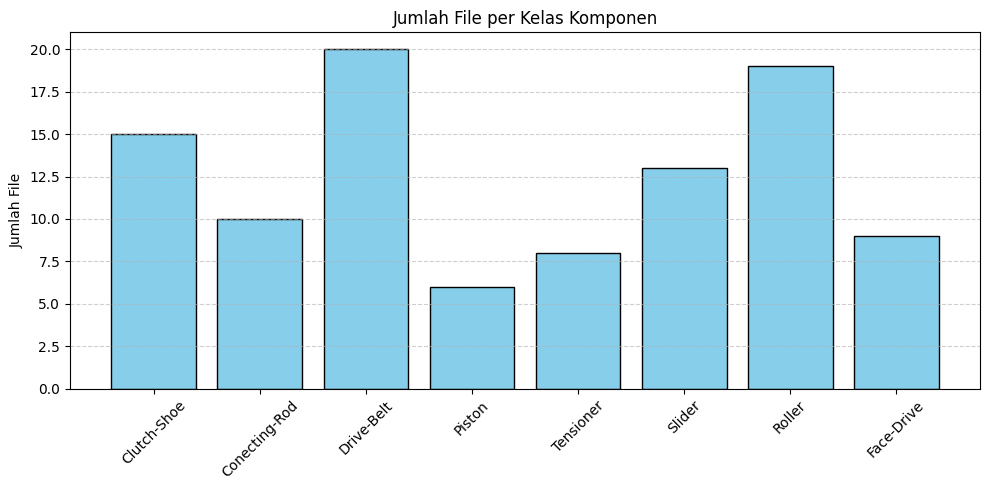

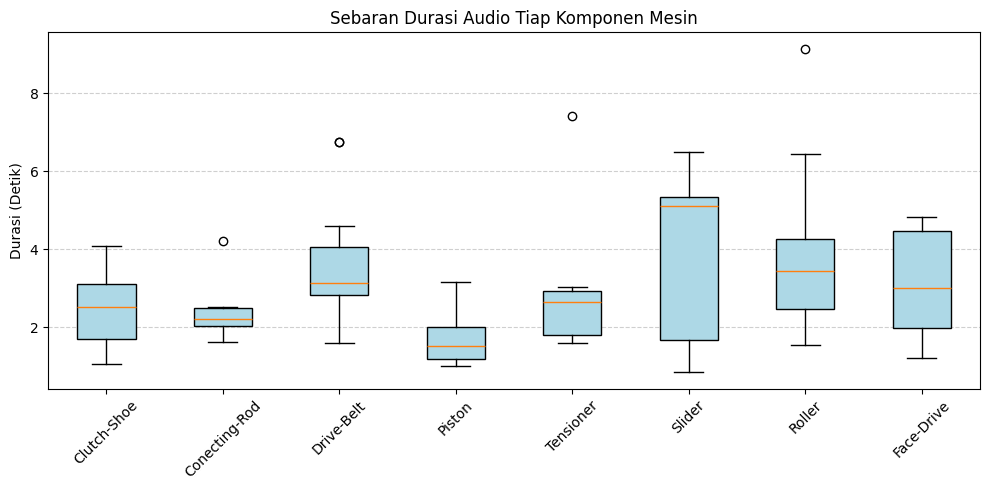

In [6]:
durasi_dict = {}
jumlah_file_dict = {}


for cls in CLASSES:
    path = os.path.join(PATHS['raw'], cls)
    if not os.path.exists(path):
        continue
        
    files = [f for f in os.listdir(path) if f.endswith(('.wav', '.mp3'))]
    durasi_list = [librosa.get_duration(path=os.path.join(path, f)) for f in files]
    
    if durasi_list:
        durasi_dict[cls] = durasi_list
        jumlah_file_dict[cls] = len(files)

plt.figure(figsize=(10, 5))
plt.bar(jumlah_file_dict.keys(), jumlah_file_dict.values(), color='skyblue', edgecolor='black')
plt.title("Jumlah File per Kelas Komponen")
plt.ylabel("Jumlah File")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.boxplot(durasi_dict.values(), tick_labels=durasi_dict.keys(), patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title("Sebaran Durasi Audio Tiap Komponen Mesin")
plt.ylabel("Durasi (Detik)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

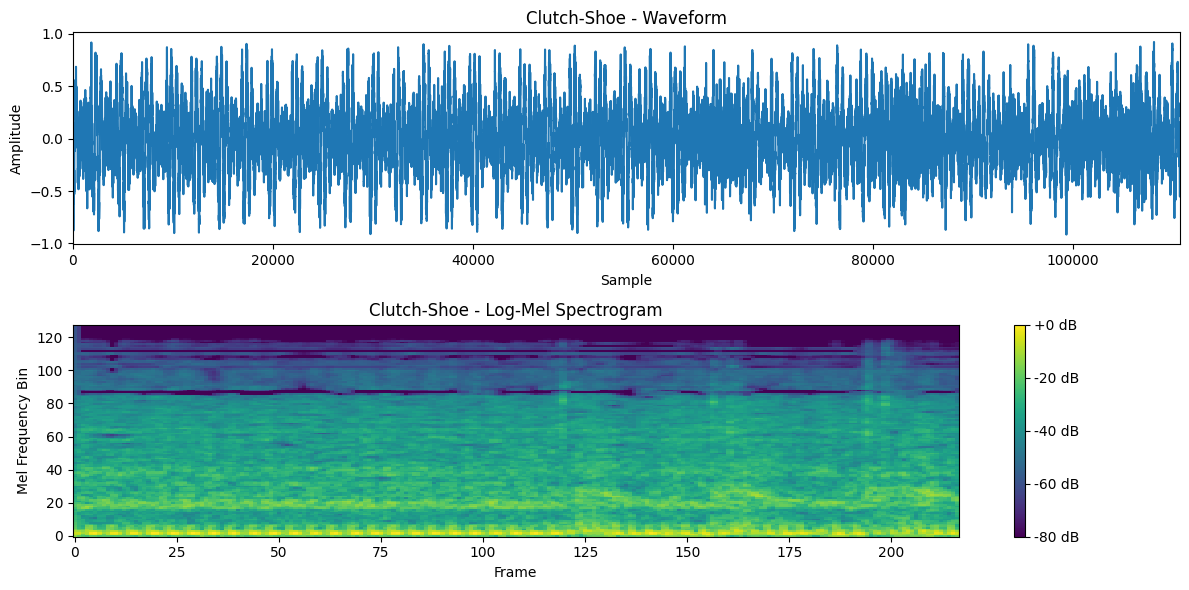

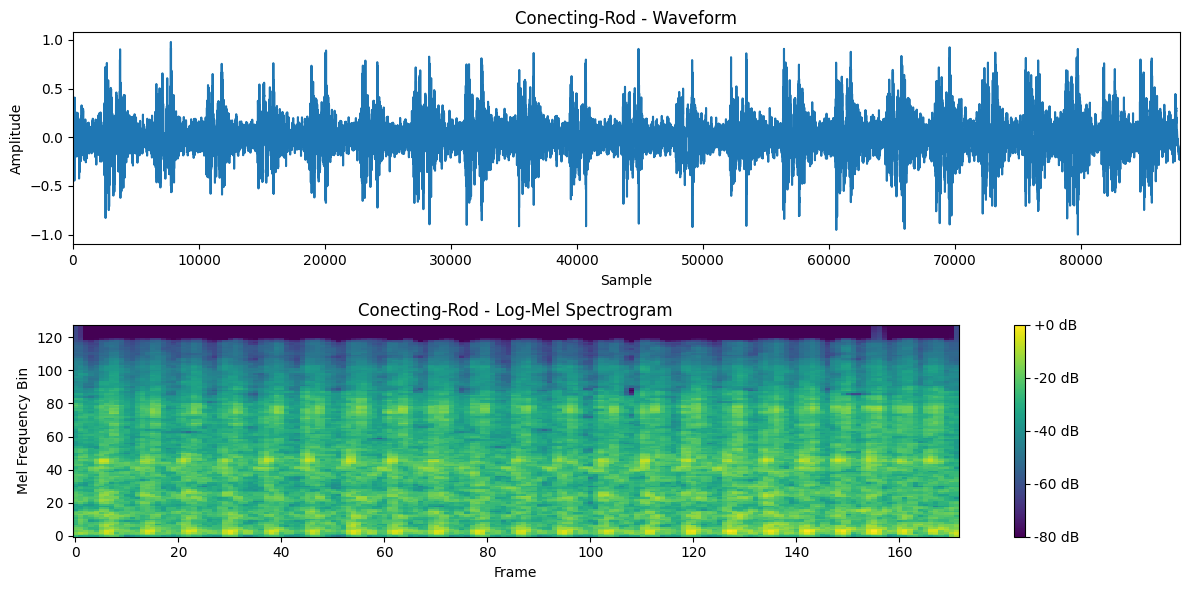

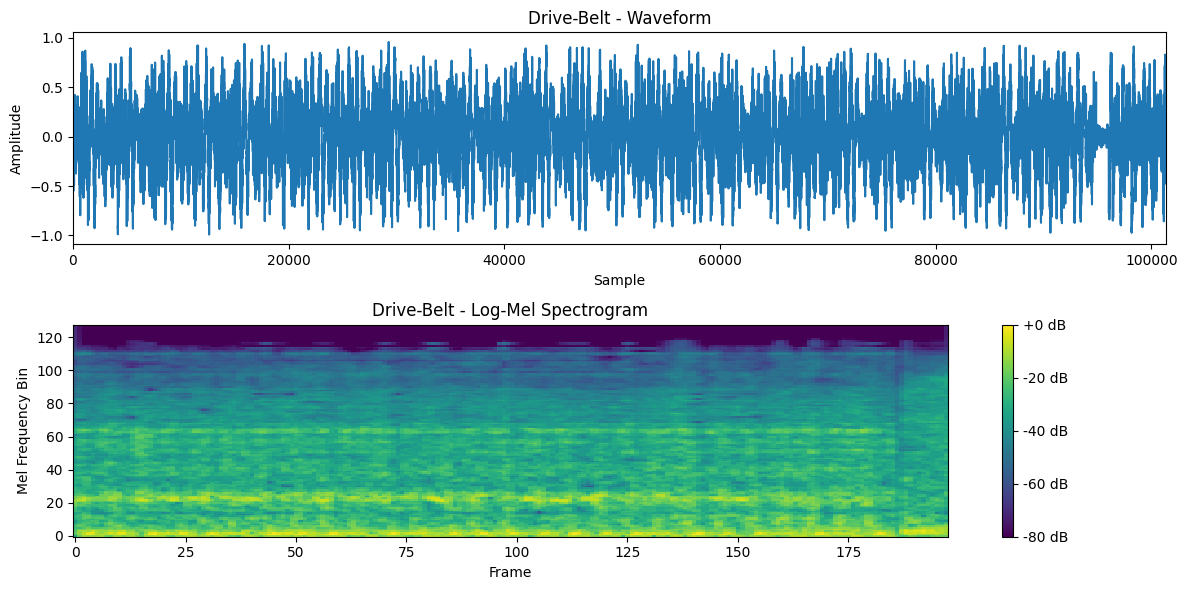

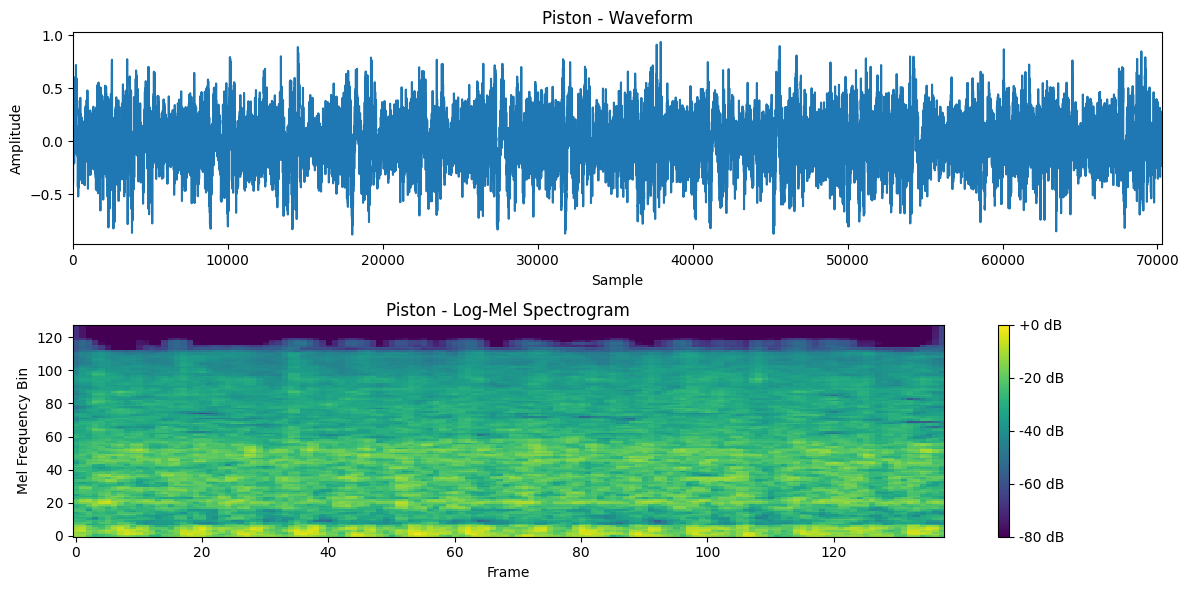

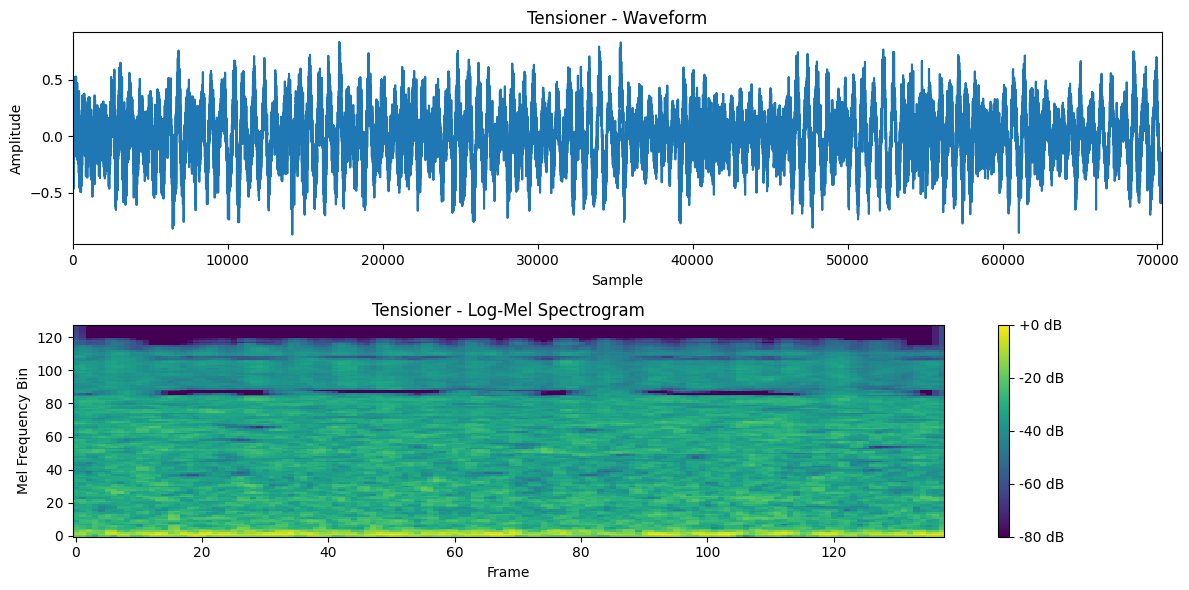

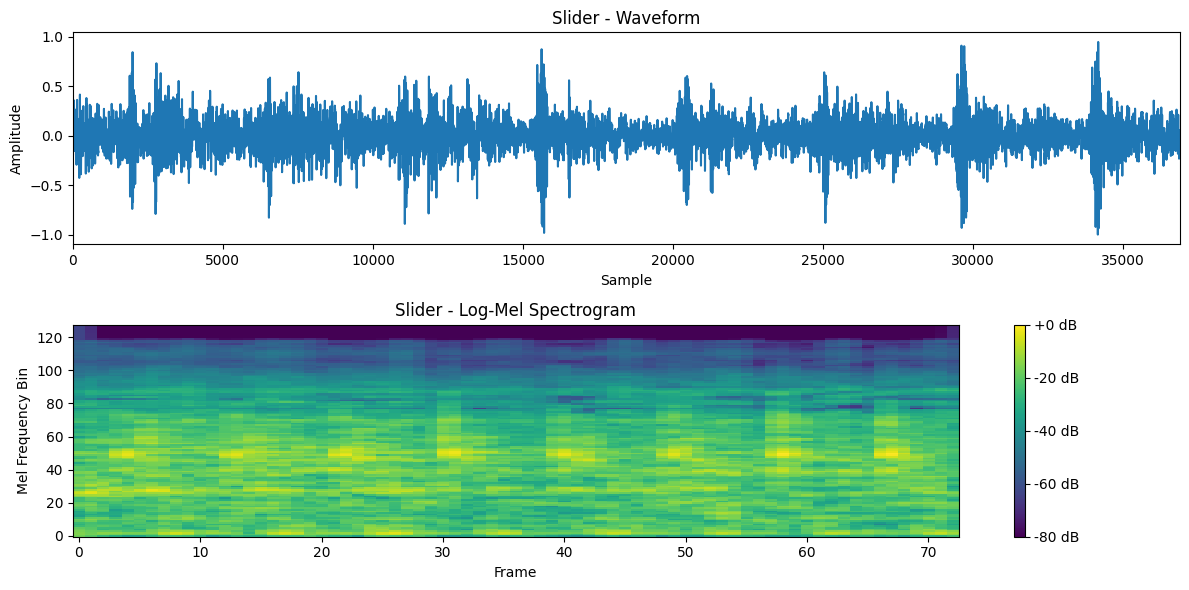

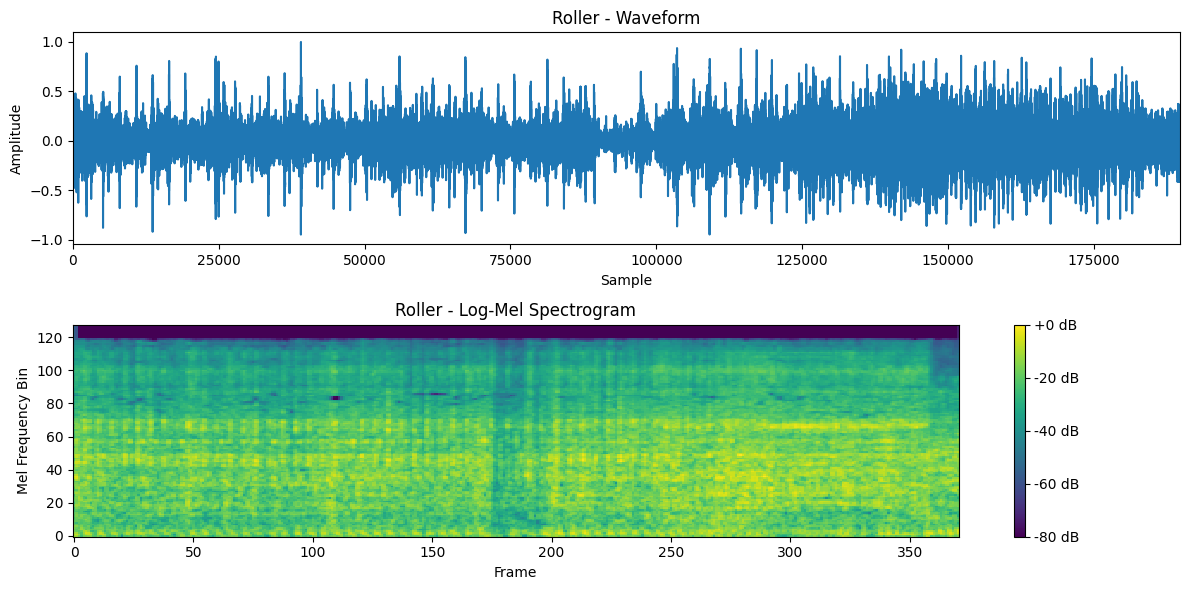

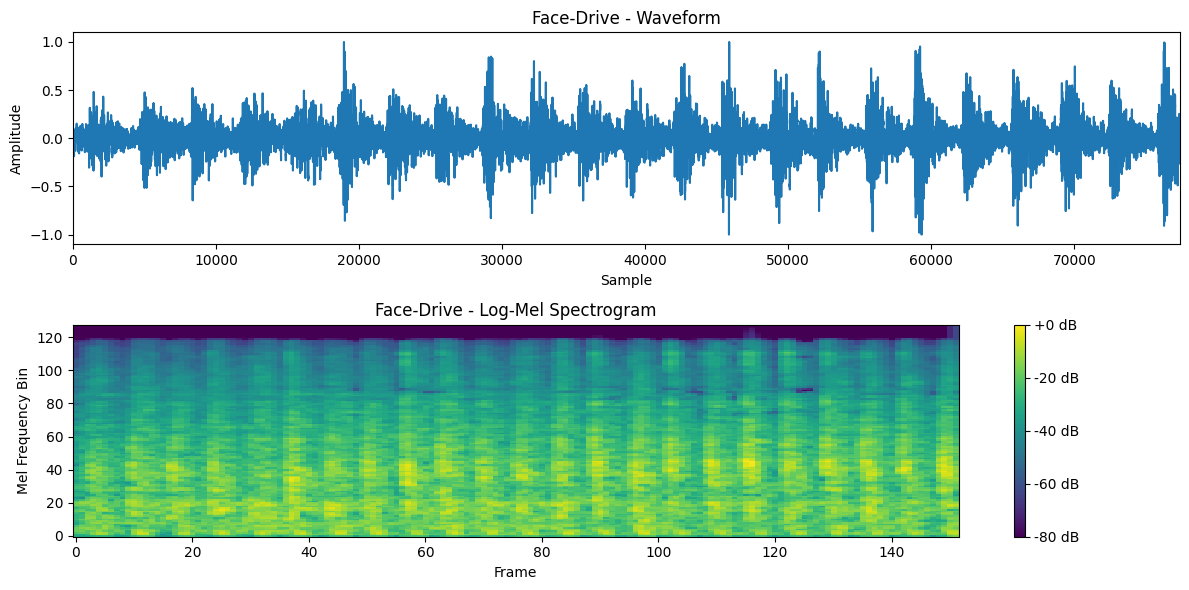

In [7]:
for cls in CLASSES:

    path = os.path.join(PATHS['raw'], cls)

    if not os.path.exists(path):
        continue

    files = sorted([
        f for f in os.listdir(path)
        if f.endswith(('.wav', '.mp3', '.m4a'))
    ])

    if not files:
        continue

    sample_file = os.path.join(path, files[0])

    y, sr = librosa.load(
        sample_file,
        sr=None
    )

    # Log-Mel Spectrogram
    mel_spec = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=128
    )

    log_mel_spec = librosa.power_to_db(
        mel_spec,
        ref=np.max
    )

    plt.figure(figsize=(12, 6))

    # ==========================
    # Waveform
    # ==========================
    plt.subplot(2, 1, 1)

    plt.plot(y)

    plt.title(
        f"{cls} - Waveform"
    )

    plt.xlabel("Sample")
    plt.ylabel("Amplitude")

    plt.xlim([0, len(y)])

    plt.subplot(2, 1, 2)

    plt.imshow(
        log_mel_spec,
        aspect='auto',
        origin='lower',
        interpolation='nearest'
    )

    plt.title(
        f"{cls} - Log-Mel Spectrogram"
    )

    plt.xlabel("Frame")
    plt.ylabel("Mel Frequency Bin")

    plt.colorbar(
        format='%+2.0f dB'
    )

    plt.tight_layout()
    plt.show()

## Preprocessing

## Split

## Modeling

## Evaluasi

## Inference